### Icefield Domain Sites Figures

created by Cassie Lumbrazo\
last updated: July 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd
from shapely.geometry import Point

In [2]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rioxarray  # For CRS handling

In [3]:
pwd

'/home/cassie/python/repos/snow_modeling_point/icefield_domain'

## All Icefield Sites

In [44]:
# Path to the UTM NetCDF file
output_merged_path = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm.nc'

# Load the dataset
ds_utm = xr.open_dataset(output_merged_path)

In [45]:
type(ds_utm)

xarray.core.dataset.Dataset

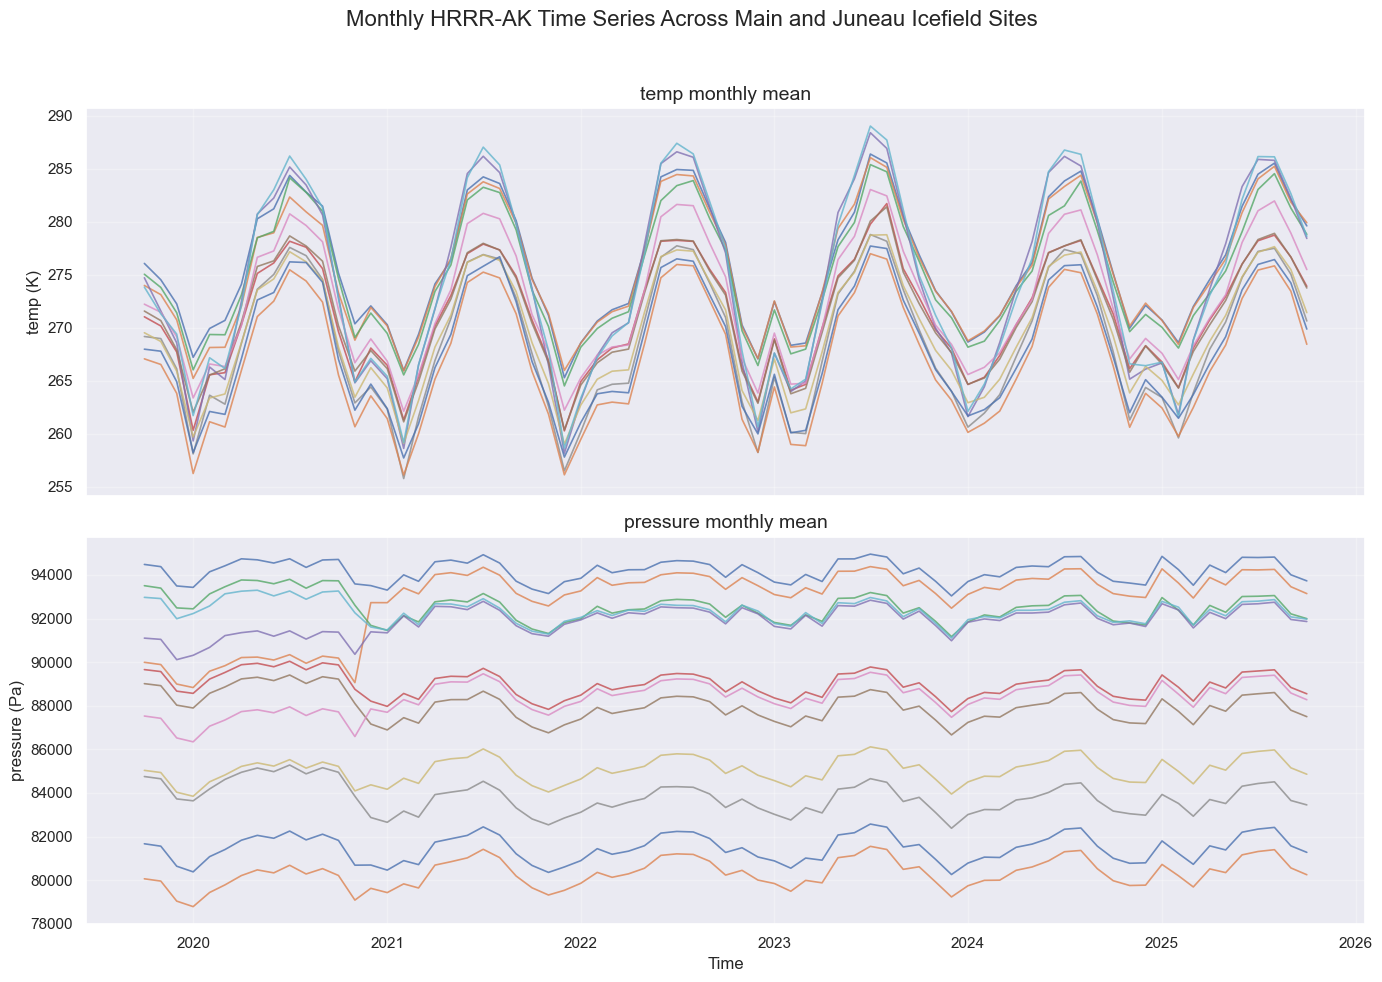

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer


ds_hrrr = ds_utm
# =============================================================================
# SITE LOCATIONS
# =============================================================================

sites_all = pd.DataFrame({
    "lat": [
        58.262, 58.2971, 58.7, 58.63447,
        59.57564, 58.64721, 58.36737, 59.01664,
        58.712433, 59.34211, 58.83497, 58.8067
    ],
    "lon": [
        -134.517, -134.386, -134.8667, -134.23708,
        -133.70982, -134.20635, -134.36638, -134.12104,
        -134.182217, -134.10221, -134.27643, -134.13613
    ]
})

sites_all["site_type"] = ["main"] * 4 + ["icefield"] * 8
sites_all["site_id"] = [f"Site {i+1}" for i in range(len(sites_all))]

# =============================================================================
# CONVERT SITE LOCATIONS TO UTM
# =============================================================================

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)

sites_all["x"], sites_all["y"] = transformer.transform(
    sites_all["lon"].values,
    sites_all["lat"].values
)

# =============================================================================
# VARIABLES TO PLOT
# =============================================================================

variables = ["temp", "pressure"]

fig, axes = plt.subplots(
    len(variables), 1,
    figsize=(14, 10),
    sharex=True
)

for i, var in enumerate(variables):
    ax = axes[i]

    for _, row in sites_all.iterrows():

        site_series = ds_hrrr[var].sel(
            x=row["x"],
            y=row["y"],
            method="nearest"
        )

        # Monthly mean
        site_series = site_series.resample(time="1MS").mean()

        time = pd.to_datetime(site_series["time"].values)

        ax.plot(
            time,
            site_series.values,
            linewidth=1.2,
            alpha=0.8
        )

    units = ds_hrrr[var].attrs.get("units", "")

    ax.set_title(f"{var} monthly mean", fontsize=14)
    ax.set_ylabel(f"{var} ({units})", fontsize=12)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time", fontsize=12)

fig.suptitle(
    "Monthly HRRR-AK Time Series Across Juneau Icefield Sites",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [47]:
print(type(ds_hrrr))
print(list(ds_hrrr.data_vars))

<class 'xarray.core.dataset.Dataset'>
['gust', 'pressure', 'orog', 'temp_surface', 'swe', 'snowdepth', 'temp', '2sh', '2d', 'rh', '10u', '10v', 'precip_rate', 'precip_total', 'gflux', 'vgtyp', 'lcc', 'mcc', 'hcc', 'tcc', 'swrad', 'lwrad', 'suswrf', 'sulwrf', 'wind', 'wind_dir', 'veg', 'lai', 'spatial_ref']


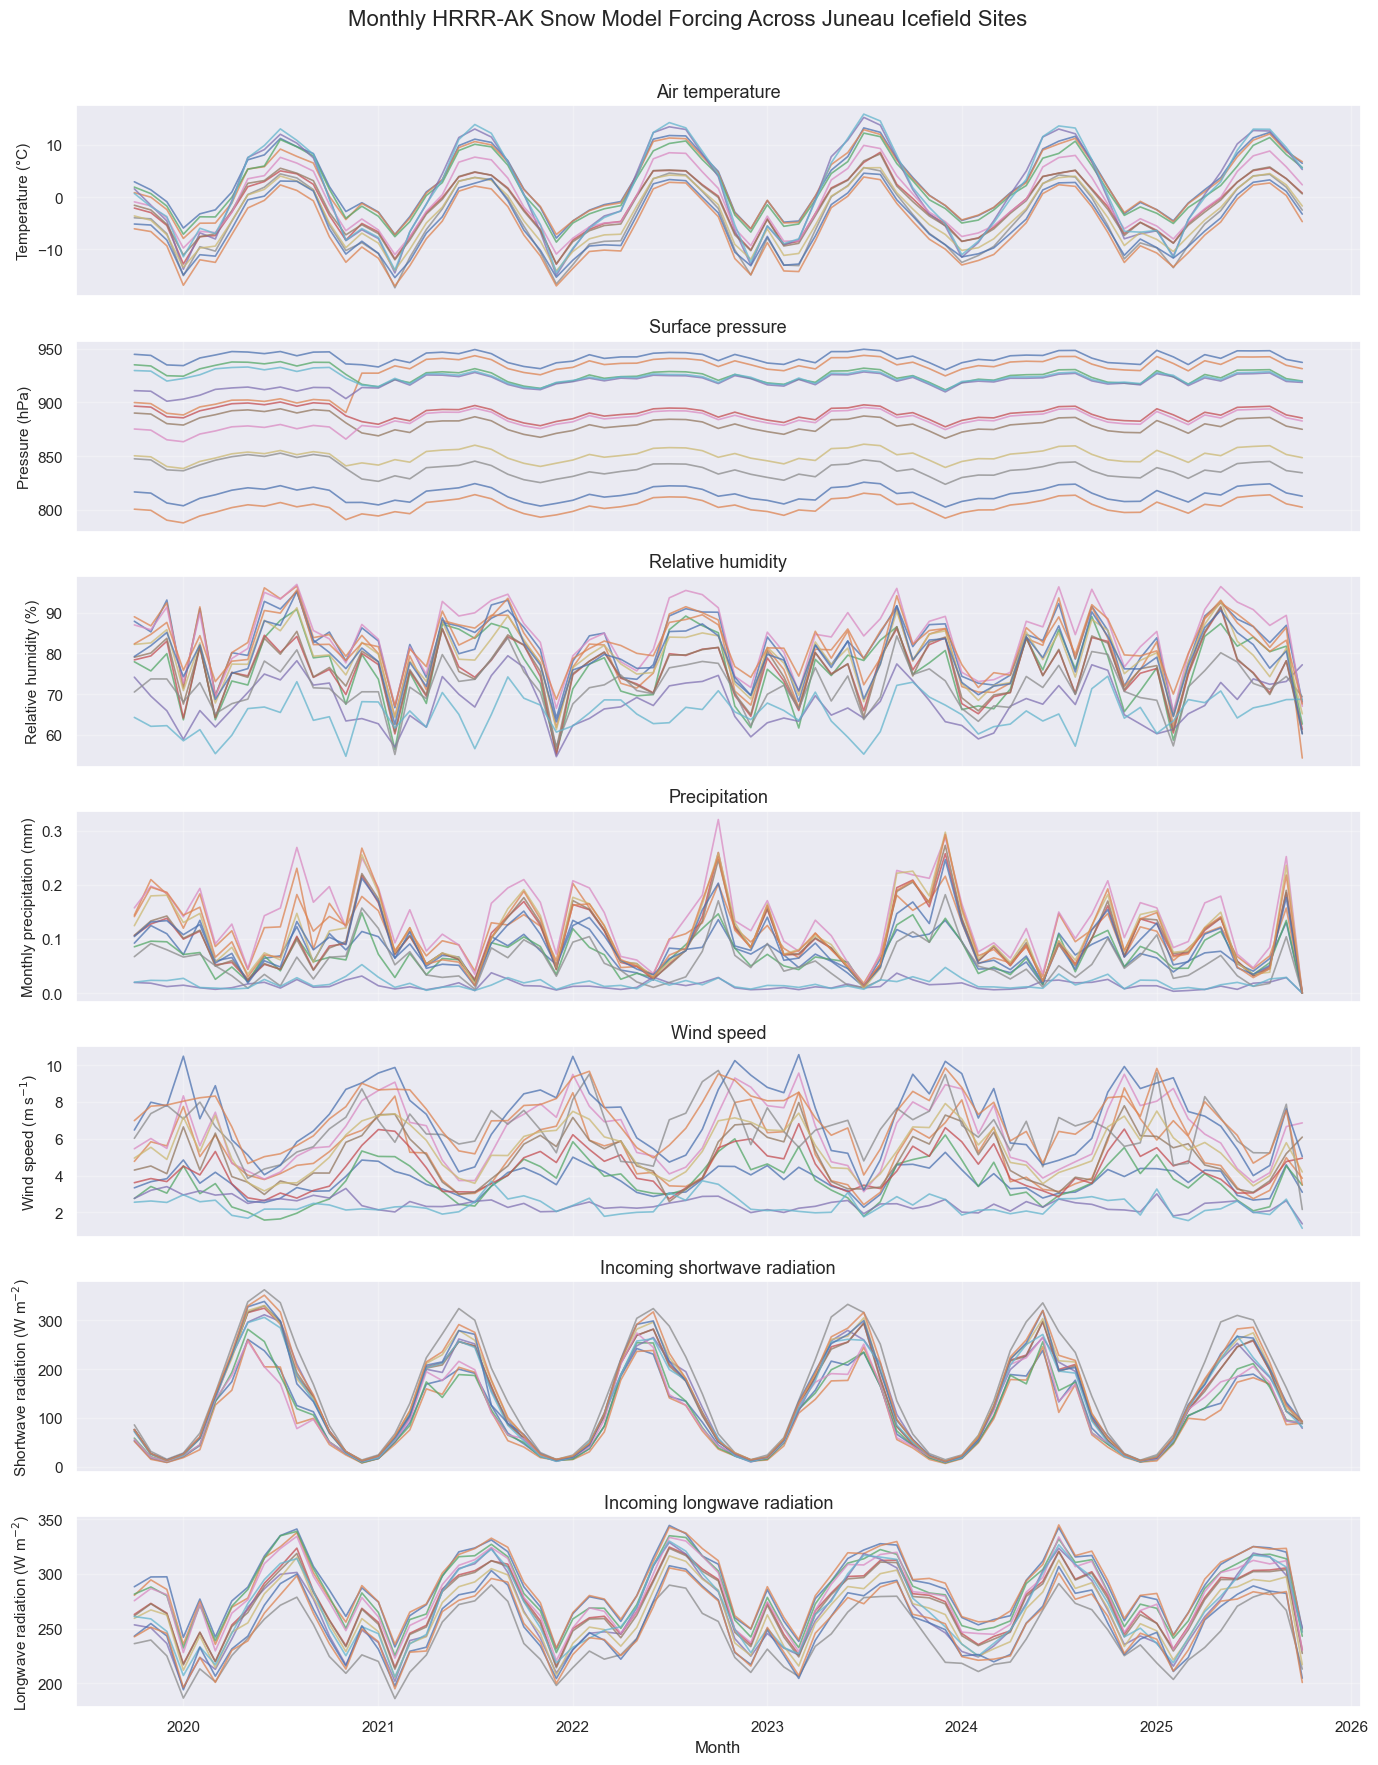

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer

# Keep xarray dataset protected from accidental overwrite
ds_hrrr = ds_utm

# =============================================================================
# SITE LOCATIONS
# =============================================================================

sites_all = pd.DataFrame({
    "lat": [
        58.262, 58.2971, 58.7, 58.63447,
        59.57564, 58.64721, 58.36737, 59.01664,
        58.712433, 59.34211, 58.83497, 58.8067
    ],
    "lon": [
        -134.517, -134.386, -134.8667, -134.23708,
        -133.70982, -134.20635, -134.36638, -134.12104,
        -134.182217, -134.10221, -134.27643, -134.13613
    ]
})

sites_all["site_type"] = ["main"] * 4 + ["icefield"] * 8
sites_all["site_id"] = [f"S{i+1:02d}" for i in range(len(sites_all))]

# Convert site lon/lat to UTM Zone 8N
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)

sites_all["x"], sites_all["y"] = transformer.transform(
    sites_all["lon"].values,
    sites_all["lat"].values
)

# =============================================================================
# OPTIONAL: CREATE WIND SPEED IF NEEDED
# =============================================================================

if "wind" not in ds_hrrr.data_vars:
    if ("10u" in ds_hrrr.data_vars) and ("10v" in ds_hrrr.data_vars):
        ds_hrrr["wind"] = np.sqrt(ds_hrrr["10u"]**2 + ds_hrrr["10v"]**2)
        ds_hrrr["wind"].attrs["units"] = "m s-1"
        ds_hrrr["wind"].attrs["long_name"] = "10 m wind speed"

# =============================================================================
# VARIABLES TO PLOT
# =============================================================================

variables = [
    "temp",
    "pressure",
    "rh",
    "precip_rate",
    "wind",
    "swrad",
    "lwrad"
]

pretty_names = {
    "temp": "Air temperature",
    "pressure": "Surface pressure",
    "rh": "Relative humidity",
    "precip_rate": "Precipitation",
    "wind": "Wind speed",
    "swrad": "Incoming shortwave radiation",
    "lwrad": "Incoming longwave radiation"
}

ylabels = {
    "temp": "Temperature (°C)",
    "pressure": "Pressure (hPa)",
    "rh": "Relative humidity (%)",
    "precip_rate": "Monthly precipitation (mm)",
    "wind": "Wind speed (m s$^{-1}$)",
    "swrad": "Shortwave radiation (W m$^{-2}$)",
    "lwrad": "Longwave radiation (W m$^{-2}$)"
}

# =============================================================================
# HELPER FUNCTION
# =============================================================================

def clean_and_monthly(da, var):
    """
    Convert units where needed and aggregate to monthly values.
    Uses monthly totals for precipitation and monthly means for all other variables.
    """

    # Temperature K to C
    if var == "temp":
        units = da.attrs.get("units", "").lower()
        if ("k" in units) or float(da.mean().values) > 100:
            da = da - 273.15

    # Pressure Pa to hPa
    if var == "pressure":
        if float(da.mean().values) > 2000:
            da = da / 100.0

    # Precipitation rate to monthly total
    if var == "precip_rate":
        units = da.attrs.get("units", "").lower()

        # kg m-2 s-1 is equivalent to mm s-1 water equivalent
        if ("s-1" in units) or ("/s" in units):
            da = da * 3600.0

        monthly = da.resample(time="1MS").sum()

    else:
        monthly = da.resample(time="1MS").mean()

    return monthly

# =============================================================================
# PLOT
# =============================================================================

fig, axes = plt.subplots(
    len(variables), 1,
    figsize=(14, 18),
    sharex=True
)

for i, var in enumerate(variables):
    ax = axes[i]

    if var not in ds_hrrr.data_vars:
        ax.text(
            0.5, 0.5,
            f"{var} not found in dataset",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )
        ax.set_title(pretty_names.get(var, var), fontsize=13)
        continue

    for _, row in sites_all.iterrows():

        site_series = ds_hrrr[var].sel(
            x=row["x"],
            y=row["y"],
            method="nearest"
        )

        site_monthly = clean_and_monthly(site_series, var)

        ax.plot(
            pd.to_datetime(site_monthly["time"].values),
            site_monthly.values,
            linewidth=1.2,
            alpha=0.75
        )

    ax.set_title(pretty_names.get(var, var), fontsize=13)
    ax.set_ylabel(ylabels.get(var, var), fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Month", fontsize=12)

fig.suptitle(
    "Monthly HRRR-AK Snow Model Forcing Across Juneau Icefield Sites",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Add a map, 

/tmp/ipykernel_404766/3625406896.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


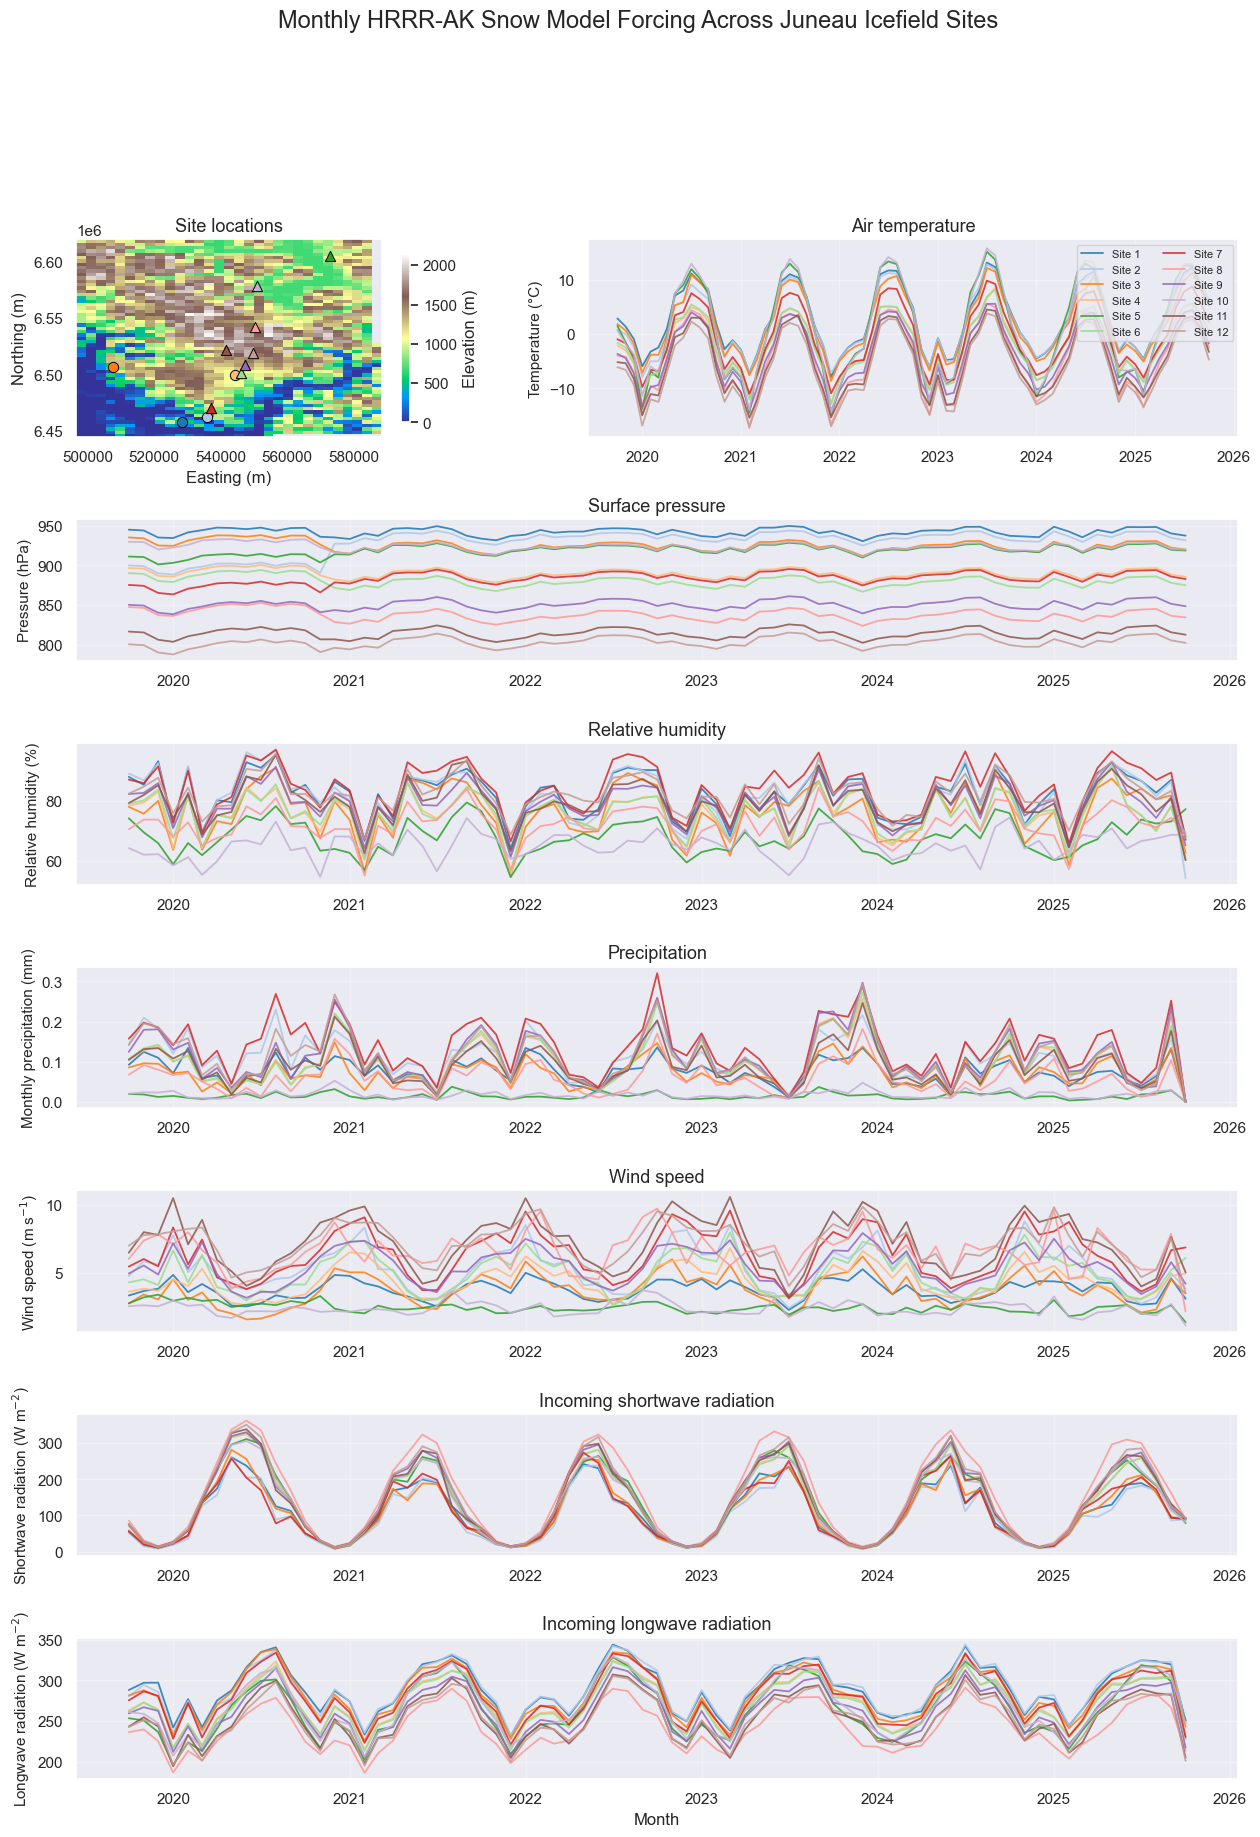

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pyproj import Transformer

# Keep dataset protected
ds_hrrr = ds_utm

# =============================================================================
# SITE LOCATIONS
# =============================================================================

sites_all = pd.DataFrame({
    "lat": [
        58.262, 58.2971, 58.7, 58.63447,
        59.57564, 58.64721, 58.36737, 59.01664,
        58.712433, 59.34211, 58.83497, 58.8067
    ],
    "lon": [
        -134.517, -134.386, -134.8667, -134.23708,
        -133.70982, -134.20635, -134.36638, -134.12104,
        -134.182217, -134.10221, -134.27643, -134.13613
    ]
})

sites_all["site_type"] = ["main"] * 4 + ["icefield"] * 8
sites_all["site_id"] = [f"Site {i+1}" for i in range(len(sites_all))]

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)
sites_all["x"], sites_all["y"] = transformer.transform(
    sites_all["lon"].values,
    sites_all["lat"].values
)

# =============================================================================
# VARIABLES
# =============================================================================

if "wind" not in ds_hrrr.data_vars and {"10u", "10v"}.issubset(ds_hrrr.data_vars):
    ds_hrrr["wind"] = np.sqrt(ds_hrrr["10u"]**2 + ds_hrrr["10v"]**2)
    ds_hrrr["wind"].attrs["units"] = "m s-1"

variables = [
    "temp",
    "pressure",
    "rh",
    "precip_rate",
    "wind",
    "swrad",
    "lwrad"
]

pretty_names = {
    "temp": "Air temperature",
    "pressure": "Surface pressure",
    "rh": "Relative humidity",
    "precip_rate": "Precipitation",
    "wind": "Wind speed",
    "swrad": "Incoming shortwave radiation",
    "lwrad": "Incoming longwave radiation"
}

ylabels = {
    "temp": "Temperature (°C)",
    "pressure": "Pressure (hPa)",
    "rh": "Relative humidity (%)",
    "precip_rate": "Monthly precipitation (mm)",
    "wind": "Wind speed (m s$^{-1}$)",
    "swrad": "Shortwave radiation (W m$^{-2}$)",
    "lwrad": "Longwave radiation (W m$^{-2}$)"
}

# One color per site
cmap = plt.get_cmap("tab20")
site_colors = {
    row["site_id"]: cmap(i)
    for i, row in sites_all.iterrows()
}

# =============================================================================
# HELPER FUNCTION
# =============================================================================

def clean_and_monthly(da, var):
    da = da.copy()

    if var == "temp":
        units = da.attrs.get("units", "").lower()
        if ("k" in units) or float(da.mean().values) > 100:
            da = da - 273.15

    if var == "pressure":
        if float(da.mean().values) > 2000:
            da = da / 100.0

    if var == "precip_rate":
        units = da.attrs.get("units", "").lower()

        # kg m-2 s-1 is equivalent to mm s-1 water equivalent
        if ("s-1" in units) or ("/s" in units):
            da = da * 3600.0

        return da.resample(time="1MS").sum()

    return da.resample(time="1MS").mean()

# =============================================================================
# FIGURE LAYOUT
# =============================================================================

fig = plt.figure(figsize=(15, 20))

gs = gridspec.GridSpec(
    nrows=len(variables),
    ncols=2,
    figure=fig,
    height_ratios=[1.4, 1, 1, 1, 1, 1, 1],
    width_ratios=[1, 1.7],
    hspace=0.55,
    wspace=0.25
)

# =============================================================================
# MAP PANEL
# =============================================================================

ax_map = fig.add_subplot(gs[0, 0])

# Use orography as background if available
if "orog" in ds_hrrr.data_vars:
    orog = ds_hrrr["orog"]

    if "time" in orog.dims:
        orog = orog.isel(time=0)

    im = ax_map.pcolormesh(
        ds_hrrr["x"],
        ds_hrrr["y"],
        orog,
        shading="auto",
        cmap="terrain"
    )

    cbar = fig.colorbar(im, ax=ax_map, shrink=0.85)
    cbar.set_label("Elevation (m)")
else:
    ax_map.set_facecolor("0.9")

for _, row in sites_all.iterrows():
    marker = "o" if row["site_type"] == "main" else "^"

    ax_map.scatter(
        row["x"],
        row["y"],
        s=55,
        marker=marker,
        color=site_colors[row["site_id"]],
        edgecolor="black",
        linewidth=0.7,
        zorder=5
    )

ax_map.set_title("Site locations", fontsize=13)
ax_map.set_xlabel("Easting (m)")
ax_map.set_ylabel("Northing (m)")
ax_map.grid(True, alpha=0.25)

# =============================================================================
# TIME SERIES PANELS
# =============================================================================

axes = []

for i, var in enumerate(variables):

    if i == 0:
        ax = fig.add_subplot(gs[0, 1])
    else:
        ax = fig.add_subplot(gs[i, :], sharex=axes[0])

    axes.append(ax)

    if var not in ds_hrrr.data_vars:
        ax.text(
            0.5, 0.5,
            f"{var} not found",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )
        continue

    for _, row in sites_all.iterrows():

        site_series = ds_hrrr[var].sel(
            x=row["x"],
            y=row["y"],
            method="nearest"
        )

        site_monthly = clean_and_monthly(site_series, var)

        ax.plot(
            pd.to_datetime(site_monthly["time"].values),
            site_monthly.values,
            color=site_colors[row["site_id"]],
            linewidth=1.3,
            alpha=0.85,
            label=row["site_id"]
        )

    ax.set_title(pretty_names[var], fontsize=13)
    ax.set_ylabel(ylabels[var], fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Month", fontsize=12)

# Legend only once
axes[0].legend(
    loc="upper right",
    fontsize=8,
    ncol=2,
    frameon=True
)

fig.suptitle(
    "Monthly HRRR-AK Snow Model Forcing Across Juneau Icefield Sites",
    fontsize=17,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

/tmp/ipykernel_404766/1017848182.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


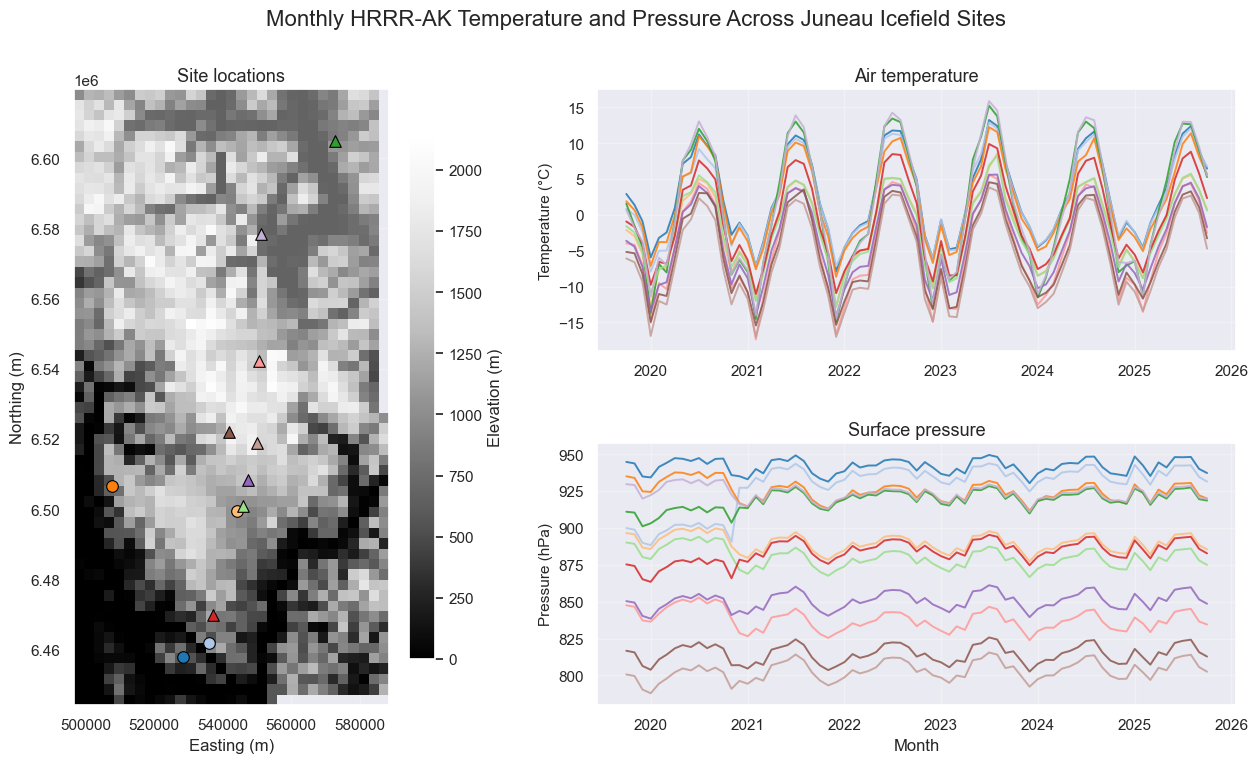

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pyproj import Transformer

# Protect original xarray dataset name
ds_hrrr = ds_utm

# =============================================================================
# SITE LOCATIONS
# =============================================================================

sites_all = pd.DataFrame({
    "lat": [
        58.262, 58.2971, 58.7, 58.63447,
        59.57564, 58.64721, 58.36737, 59.01664,
        58.712433, 59.34211, 58.83497, 58.8067
    ],
    "lon": [
        -134.517, -134.386, -134.8667, -134.23708,
        -133.70982, -134.20635, -134.36638, -134.12104,
        -134.182217, -134.10221, -134.27643, -134.13613
    ]
})

sites_all["site_type"] = ["main"] * 4 + ["icefield"] * 8
sites_all["site_id"] = [f"Site {i+1}" for i in range(len(sites_all))]

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)
sites_all["x"], sites_all["y"] = transformer.transform(
    sites_all["lon"].values,
    sites_all["lat"].values
)

# =============================================================================
# VARIABLES
# =============================================================================

variables = ["temp", "pressure"]

pretty_names = {
    "temp": "Air temperature",
    "pressure": "Surface pressure"
}

ylabels = {
    "temp": "Temperature (°C)",
    "pressure": "Pressure (hPa)"
}

# One color per site
cmap = plt.get_cmap("tab20")
site_colors = {
    row["site_id"]: cmap(i)
    for i, row in sites_all.iterrows()
}

# =============================================================================
# HELPER FUNCTION
# =============================================================================

def clean_and_monthly(da, var):
    da = da.copy()

    if var == "temp":
        units = da.attrs.get("units", "").lower()
        if ("k" in units) or float(da.mean().values) > 100:
            da = da - 273.15

    if var == "pressure":
        if float(da.mean().values) > 2000:
            da = da / 100.0

    return da.resample(time="1MS").mean()

# =============================================================================
# FIGURE LAYOUT
# =============================================================================

fig = plt.figure(figsize=(15, 8))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[1.05, 1.7],
    height_ratios=[1, 1],
    wspace=0.25,
    hspace=0.35
)

ax_map = fig.add_subplot(gs[:, 0])
ax_temp = fig.add_subplot(gs[0, 1])
ax_pressure = fig.add_subplot(gs[1, 1], sharex=ax_temp)

# =============================================================================
# MAP PANEL
# =============================================================================

if "orog" in ds_hrrr.data_vars:
    orog = ds_hrrr["orog"]

    if "time" in orog.dims:
        orog = orog.isel(time=0)

    im = ax_map.pcolormesh(
        ds_hrrr["x"],
        ds_hrrr["y"],
        orog,
        shading="auto",
        cmap="Greys_r", 
        alpha=0.6,
    )

    cbar = fig.colorbar(im, ax=ax_map, shrink=0.85)
    cbar.set_label("Elevation (m)")
else:
    ax_map.set_facecolor("0.9")

for _, row in sites_all.iterrows():
    marker = "o" if row["site_type"] == "main" else "^"

    ax_map.scatter(
        row["x"],
        row["y"],
        s=70,
        marker=marker,
        color=site_colors[row["site_id"]],
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

ax_map.set_title("Site locations", fontsize=13)
ax_map.set_xlabel("Easting (m)")
ax_map.set_ylabel("Northing (m)")
ax_map.grid(True, alpha=0.25)

# =============================================================================
# TIME SERIES PANELS
# =============================================================================

for ax, var in zip([ax_temp, ax_pressure], variables):

    for _, row in sites_all.iterrows():

        site_series = ds_hrrr[var].sel(
            x=row["x"],
            y=row["y"],
            method="nearest"
        )

        site_monthly = clean_and_monthly(site_series, var)

        ax.plot(
            pd.to_datetime(site_monthly["time"].values),
            site_monthly.values,
            color=site_colors[row["site_id"]],
            linewidth=1.4,
            alpha=0.85,
            label=row["site_id"]
        )

    ax.set_title(pretty_names[var], fontsize=13)
    ax.set_ylabel(ylabels[var], fontsize=11)
    ax.grid(True, alpha=0.3)

ax_pressure.set_xlabel("Month", fontsize=12)

# ax_temp.legend(
#     # loc="upper right",
#     fontsize=8,
#     ncol=2,
#     frameon=True
# )

fig.suptitle(
    "Monthly HRRR-AK Temperature and Pressure Across Juneau Icefield Sites",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_404766/488205837.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


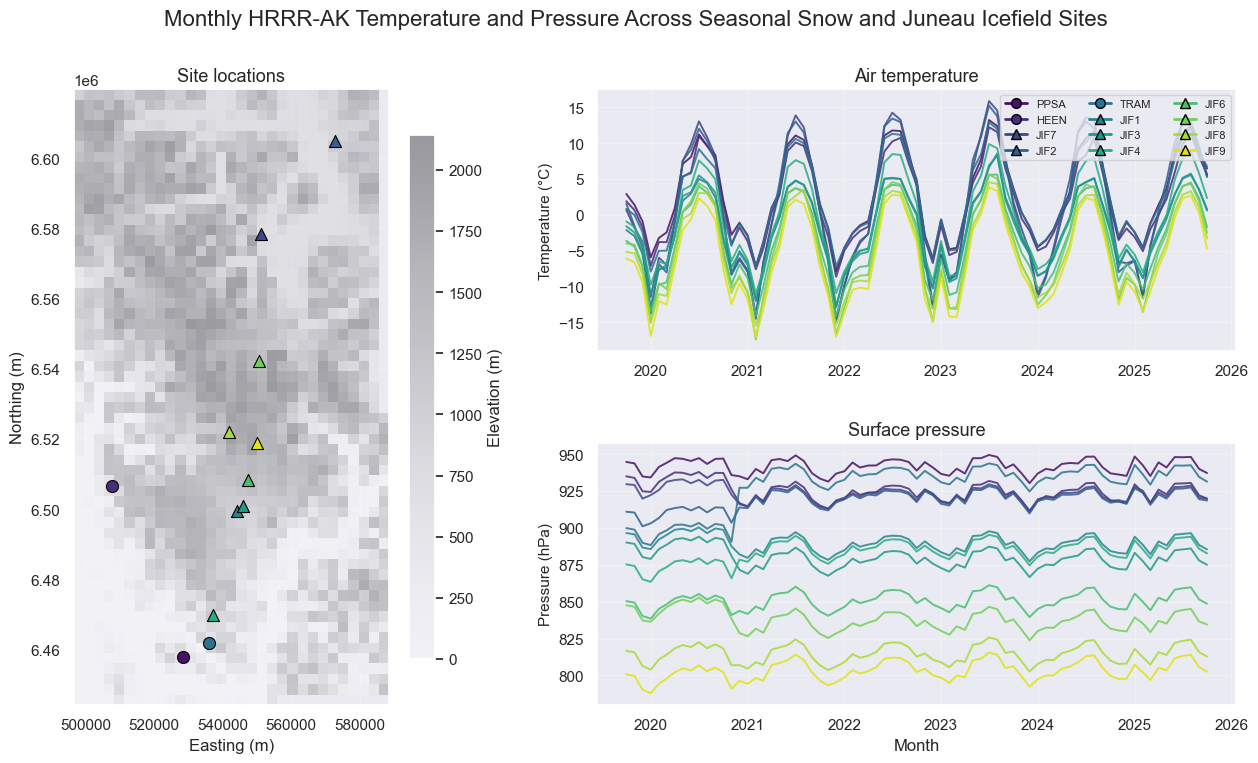

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pyproj import Transformer
from matplotlib.lines import Line2D

# Protect original xarray dataset name
ds_hrrr = ds_utm

# =============================================================================
# SITE LOCATIONS
# =============================================================================

sites_all = pd.DataFrame({
    "lat": [
        58.262, 58.2971, 58.7, 58.63447,
        59.57564, 58.64721, 58.36737, 59.01664,
        58.712433, 59.34211, 58.83497, 58.8067
    ],
    "lon": [
        -134.517, -134.386, -134.8667, -134.23708,
        -133.70982, -134.20635, -134.36638, -134.12104,
        -134.182217, -134.10221, -134.27643, -134.13613
    ]
})

sites_all["site_type"] = ["main"] * 3 + ["icefield"] * 9

# Assign fixed site IDs
sites_all["site_id"] = [
    "PPSA",
    "TRAM",
    "HEEN",
    "JIF1",
    "JIF2",
    "JIF3",
    "JIF4",
    "JIF5",
    "JIF6",
    "JIF7",
    "JIF8",
    "JIF9"
]

# =============================================================================
# FIXED SITE COLORS
# =============================================================================

site_colors = {
    "PPSA":  "tab:blue",
    "TRAM":  "tab:green",
    "HEEN":  "tab:red",
    "JIF1":  "tab:orange",
    "JIF2":  "tab:purple",
    "JIF3":  "tab:pink",
    "JIF4":  "tab:cyan",
    "JIF5":  "gold",
    "JIF6":  "darkviolet",
    "JIF7":  "limegreen",
    "JIF8":  "black",
    "JIF9": "tab:brown",
}

# =============================================================================
# PROJECT SITE LOCATIONS TO UTM
# =============================================================================

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)

sites_all["x"], sites_all["y"] = transformer.transform(
    sites_all["lon"].values,
    sites_all["lat"].values
)

# =============================================================================
# GET MODEL ELEVATION AT EACH SITE
# =============================================================================

site_elevations = []

for _, row in sites_all.iterrows():

    elev = (
        ds_hrrr["orog"]
        .isel(time=0)
        .sel(x=row["x"], y=row["y"], method="nearest")
        .item()
    )

    site_elevations.append(elev)

sites_all["elevation"] = site_elevations

# Sort from lowest to highest elevation
sites_all = sites_all.sort_values("elevation").reset_index(drop=True)

# =============================================================================
# COLORS (LOWEST → HIGHEST ELEVATION)
# =============================================================================

colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(sites_all)))

site_colors = {
    row["site_id"]: colors[i]
    for i, (_, row) in enumerate(sites_all.iterrows())
}

# =============================================================================
# VARIABLES
# =============================================================================

variables = ["temp", "pressure"]

pretty_names = {
    "temp": "Air temperature",
    "pressure": "Surface pressure"
}

ylabels = {
    "temp": "Temperature (°C)",
    "pressure": "Pressure (hPa)"
}

# =============================================================================
# HELPER FUNCTION
# =============================================================================

def clean_and_monthly(da, var):
    da = da.copy()

    if var == "temp":
        units = da.attrs.get("units", "").lower()
        if ("k" in units) or float(da.mean().values) > 100:
            da = da - 273.15

    if var == "pressure":
        if float(da.mean().values) > 2000:
            da = da / 100.0

    return da.resample(time="1MS").mean()

# =============================================================================
# FIGURE LAYOUT
# =============================================================================

fig = plt.figure(figsize=(15, 8))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[1.05, 1.7],
    height_ratios=[1, 1],
    wspace=0.25,
    hspace=0.35
)

ax_map = fig.add_subplot(gs[:, 0])
ax_temp = fig.add_subplot(gs[0, 1])
ax_pressure = fig.add_subplot(gs[1, 1], sharex=ax_temp)

# =============================================================================
# MAP PANEL
# =============================================================================

if "orog" in ds_hrrr.data_vars:
    orog = ds_hrrr["orog"]

    if "time" in orog.dims:
        orog = orog.isel(time=0)

    im = ax_map.pcolormesh(
        ds_hrrr["x"],
        ds_hrrr["y"],
        orog,
        shading="auto",
        cmap="Greys",
        alpha=0.35
    )

    cbar = fig.colorbar(im, ax=ax_map, shrink=0.85)
    cbar.set_label("Elevation (m)")
else:
    ax_map.set_facecolor("0.9")

for _, row in sites_all.iterrows():
    marker = "o" if row["site_type"] == "main" else "^"

    ax_map.scatter(
        row["x"],
        row["y"],
        s=75,
        marker=marker,
        color=site_colors[row["site_id"]],
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

ax_map.set_title("Site locations", fontsize=13)
ax_map.set_xlabel("Easting (m)")
ax_map.set_ylabel("Northing (m)")
ax_map.grid(True, alpha=0.25)

# =============================================================================
# TIME SERIES PANELS
# =============================================================================

for ax, var in zip([ax_temp, ax_pressure], variables):

    for _, row in sites_all.iterrows():

        site_series = ds_hrrr[var].sel(
            x=row["x"],
            y=row["y"],
            method="nearest"
        )

        site_monthly = clean_and_monthly(site_series, var)

        ax.plot(
            pd.to_datetime(site_monthly["time"].values),
            site_monthly.values,
            color=site_colors[row["site_id"]],
            linewidth=1.4,
            alpha=0.85,
            label=row["site_id"]
        )

    ax.set_title(pretty_names[var], fontsize=13)
    ax.set_ylabel(ylabels[var], fontsize=11)
    ax.grid(True, alpha=0.3)

ax_pressure.set_xlabel("Month", fontsize=12)

# =============================================================================
# LEGEND
# =============================================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        color=site_colors[row["site_id"]],
        lw=2,
        marker="o" if row["site_type"] == "main" else "^",
        markeredgecolor="black",
        markersize=7,
        label=row["site_id"]
    )
    for _, row in sites_all.iterrows()
]

ax_temp.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=8,
    ncol=3,
    frameon=True
)

fig.suptitle(
    "Monthly HRRR-AK Temperature and Pressure Across Seasonal Snow and Juneau Icefield Sites",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()